# Type B — EOD Trailing Drawdown Challenge Insurance

**What you're doing:** Same as Type A — buy a challenge, hedge through phases, get funded — but the drawdown rules are harder.

**What "Trailing Drawdown" means:** The max drawdown floor **moves up** as your balance grows. A $100k account with 10% trailing DD starts with a floor at $90k. If you profit $5k (balance $105k), the floor moves up to $94.5k. Your safety cushion stays the same percentage, but the absolute floor keeps rising.

**Why this matters for hedging:** Each day you pass (gain profit), the next day's hedge is more expensive because:
1. Your cost stack grew (you paid for today's hedge loss)
2. The hedge needs to be bigger to protect the growing cost stack
3. This creates **compounding costs** — each day amplifies the next

**Minimum trading days are critical here.** If you must trade for 5 days to pass, the target is split into 5 daily chunks. Each day the trailing floor moves up, making the next day's hedge slightly larger.

## The Numbers

$$\text{Daily Target} = \frac{\text{Phase Target}}{\text{Min Trading Days}}$$

$$\text{Each day: } L_{n+1} = L_n + \frac{L_n}{\text{DD\%}} \times \text{Daily Target} + \text{Spread}$$

$$\text{EV} = \text{Funded Payout} - \text{Total Cost}$$

> The daily compounding makes trailing drawdown challenges more expensive to hedge than static ones.

## Setup

In [ ]:
import sqlite3, json, os, math, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DB_PATH = os.path.join(
    os.environ.get("WORKSPACE_ROOT", r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"),
    "Business", "STRATEGY", "resources", "PropFirmData", "propmatch_model_input.db"
)
EXEC_PATH = os.path.abspath(os.path.join(os.path.dirname(DB_PATH), "..", "..", "executions"))
if EXEC_PATH not in sys.path:
    sys.path.insert(0, EXEC_PATH)

# ── Assumptions ──
FUNDED_TARGET = 0.08
SPREAD_COST   = 0.0003
LEVERAGE      = 100

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print(f"Type B notebook ready.")
print(f"Funded target: {FUNDED_TARGET*100:.0f}%  |  Spread: {SPREAD_COST*100:.2f}%  |  Leverage: 1:{LEVERAGE}")

Type B notebook ready.
Funded target: 8%  |  Spread: 0.03%  |  Leverage: 1:100


## Load Trailing Drawdown Challenges

In [2]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("SELECT * FROM v_model_inputs WHERE survival_model_class = 'challenge_trailing' ORDER BY account_size, fee_assumed").fetchall()
conn.close()

challenges = []
for row in rows:
    d = dict(row)
    pt = d.pop("profit_targets", None)
    if isinstance(pt, str):
        try:
            d["profit_targets"] = json.loads(pt)
        except (json.JSONDecodeError, TypeError):
            d["profit_targets"] = []
    else:
        d["profit_targets"] = pt or []
    challenges.append(d)

df_raw = pd.DataFrame(challenges)
print(f"Loaded {len(challenges)} trailing-drawdown challenges")
print(f"Firms: {df_raw['firm'].nunique()}")
print(f"Account sizes: {sorted(df_raw['account_size'].unique())}")
if 'min_trading_days' in df_raw.columns:
    print(f"Min trading days range: {df_raw['min_trading_days'].min()} – {df_raw['min_trading_days'].max()}")

Loaded 20 trailing-drawdown challenges
Firms: 4
Account sizes: [np.int64(5000), np.int64(10000), np.int64(15000), np.int64(25000), np.int64(50000), np.int64(100000), np.int64(150000), np.int64(200000), np.int64(400000)]
Min trading days range: 3 – 5


## Type B Math Engine — Daily Compounding

The key difference from Type A: **the hedge re-sizes every day**.

Each trading day:
1. Calculate today's hedge size = total costs so far ÷ DD%
2. You gain daily target on the prop account → hedge loses that amount
3. Pay spread on the round-trip trade
4. Tomorrow's cost stack is bigger → tomorrow's hedge is bigger → costs compound

This is why min_trading_days matters so much. More days = more compounding rounds = higher total cost.

$$L_{\text{day }n+1} = L_{\text{day }n} \times \left(1 + \frac{\text{daily target}}{\text{DD\%}} + \frac{2 \times \text{spread}}{\text{DD\%}}\right)$$

In [ ]:
from notebook_review_adjustment import build_review_adjusted_dataframe

def compute_type_b(challenge, funded_target=FUNDED_TARGET, spread_cost=SPREAD_COST):
    S = challenge['account_size']
    fee = challenge.get('fee_assumed') or challenge.get('fee_discounted') or 0
    activation_fee = challenge.get('activation_fee') or 0
    targets = challenge.get('profit_targets') or []
    steps = challenge.get('steps') or len(targets) or 2
    dd_pct = (challenge.get('max_drawdown_pct') or 10) / 100
    split = (challenge.get('profit_split_pct') or 80) / 100
    min_days = max(int(challenge.get('min_trading_days') or 1), 1)
    if isinstance(targets, str):
        targets = json.loads(targets)
    phase_targets = [t / 100 for t in targets] if targets else [0.08 / steps] * steps

    L = float(fee)
    phases = []
    daily_log = []  # track each day for visualization

    for i in range(steps):
        target = phase_targets[i] if i < len(phase_targets) else phase_targets[-1]
        L_start = L
        daily_target = target / min_days

        # Walk day-by-day: trailing DD means hedge re-sizes each day
        for day in range(min_days):
            hedge_size = L / dd_pct if dd_pct > 0 else 0
            daily_loss = hedge_size * daily_target
            spread_day = hedge_size * spread_cost * 2
            L += daily_loss + spread_day
            daily_log.append({
                'phase': i + 1, 'day': day + 1,
                'hedge_size': round(hedge_size, 2),
                'daily_loss': round(daily_loss, 2),
                'spread': round(spread_day, 2),
                'cost_after': round(L, 2),
            })

        phase_cost = L - L_start
        final_hedge = L / dd_pct if dd_pct > 0 else 0
        margin = final_hedge / LEVERAGE
        buffer = final_hedge * dd_pct * 1.5

        phases.append({
            'phase': i + 1, 'target_pct': round(target * 100, 2),
            'daily_target_pct': round(daily_target * 100, 4),
            'min_trading_days': min_days,
            'cost_before': round(L_start, 2), 'cost_after': round(L, 2),
            'phase_cost': round(phase_cost, 2),
            'final_hedge_size': round(final_hedge, 2),
            'capital_needed': round(margin + buffer, 2),
        })

    L += float(activation_fee)
    total_cost = L
    funded_payout = S * funded_target * split
    EV = funded_payout - total_cost
    cap = max(ph['capital_needed'] for ph in phases) if phases else 0

    return {
        'firm': challenge.get('firm'), 'account_size': S,
        'fee': round(fee, 2), 'activation_fee': round(activation_fee, 2),
        'steps': steps, 'max_drawdown_pct': round(dd_pct * 100, 2),
        'profit_split_pct': round(split * 100, 1), 'min_trading_days': min_days,
        'phases': phases, 'daily_log': daily_log,
        'total_cost': round(total_cost, 2), 'funded_payout': round(funded_payout, 2),
        'EV': round(EV, 2),
        'breakeven_pct': round((total_cost / split / S) * 100, 2) if S > 0 else 0,
        'capital_needed': round(cap, 2),
        'capital_efficiency': round(EV / cap, 4) if cap > 0 else 0,
    }

results = [compute_type_b(c) for c in challenges]
df = build_review_adjusted_dataframe(
    results,
    challenges,
    raw_ev_col='EV',
    revenue_cols=['funded_payout'],
    capital_col='capital_needed',
    fee_col='fee',
)

pos_raw = (df['EV'] > 0).sum()
pos_adj = (df['EV_review_adj'] > 0).sum()
print(f"Positive EV (raw):        {pos_raw}/{len(df)} challenges")
print(f"Positive EV (review-adj): {pos_adj}/{len(df)} challenges")
print(f"Average EV (raw):         ${df['EV'].mean():,.2f}")
print(f"Average EV (review-adj):  ${df['EV_review_adj'].mean():,.2f}")
if pos_adj > 0:
    best = df.loc[df['EV_review_adj'].idxmax()]
    print(
        f"Best review-adj EV: {best['firm']} ${best['account_size']:,.0f} "
        f"→ ${best['EV_review_adj']:,.2f} (raw ${best['EV']:,.2f}, factor {best['review_factor']:.3f})"
    )
print(f"\nAll have min_trading_days:")
print(df[['firm','account_size','min_trading_days','total_cost','EV','EV_review_adj']].to_string(index=False))

Positive EV: 20/20 challenges
Average EV:  $3,656.88
Best EV:     FXIFY $400,000 → $13,145.27

All have min_trading_days:
              firm  account_size  min_trading_days  total_cost       EV
        AquaFunded          5000                 5      122.44   237.56
     Blue Guardian          5000                 4      134.05   205.95
             FXIFY          5000                 5      249.09    70.91
        AquaFunded         10000                 5      291.31   428.69
     Blue Guardian         10000                 4      294.18   385.82
             FXIFY         10000                 5      375.75   264.25
             FXIFY         15000                 5      502.41   457.59
        AquaFunded         25000                 5      527.74  1272.26
     Blue Guardian         25000                 4      525.05  1174.95
             FXIFY         25000                 5      840.17   759.83
     Blue Guardian         50000                 4      930.93  2469.07
             F

## Type B Rankings

In [ ]:
rank_cols = ['firm', 'account_size', 'review_rating', 'review_count', 'review_factor', 'fee', 'activation_fee', 'steps',
             'max_drawdown_pct', 'profit_split_pct', 'min_trading_days',
             'total_cost', 'funded_payout', 'funded_payout_review_adj', 'EV', 'EV_review_adj', 'breakeven_pct',
             'capital_needed', 'capital_efficiency_review_adj']

df.sort_values('EV_review_adj', ascending=False)[rank_cols].style.format({
    'review_rating': '{:.1f}',
    'review_count': '{:,.0f}',
    'review_factor': '{:.3f}',
    'fee': '${:,.0f}', 'activation_fee': '${:,.0f}',
    'total_cost': '${:,.2f}', 'funded_payout': '${:,.2f}', 'funded_payout_review_adj': '${:,.2f}',
    'EV': '${:,.2f}', 'EV_review_adj': '${:,.2f}',
    'breakeven_pct': '{:.1f}%', 'capital_needed': '${:,.0f}',
    'capital_efficiency_review_adj': '{:.4f}', 'max_drawdown_pct': '{:.1f}%',
    'profit_split_pct': '{:.0f}%', 'account_size': '${:,}',
}).bar(subset=['EV_review_adj'], color='#5fba7d').set_caption(
    f'Type B: Trailing Drawdown Insurance — All Challenges by Review-Adjusted EV (funded target: {FUNDED_TARGET*100:.0f}%)')

,firm,account_size,fee,activation_fee,steps,max_drawdown_pct,profit_split_pct,min_trading_days,total_cost,funded_payout,EV,breakeven_pct,capital_needed,capital_efficiency
19,FXIFY,"$400,000","$2,950",$0,2,10.0%,80%,5,"$12,454.73","$25,600.00","$13,145.27",3.9%,"$19,928",0.6597
16,AquaFunded,"$200,000",$897,$0,2,10.0%,90%,5,"$3,787.08","$14,400.00","$10,612.92",2.1%,"$6,059",1.7515
17,Blue Guardian,"$200,000",$921,$0,2,10.0%,85%,4,"$3,429.56","$13,600.00","$10,170.44",2.0%,"$5,487",1.8535
18,FXIFY,"$200,000","$1,049",$0,2,10.0%,80%,5,"$4,428.82","$12,800.00","$8,371.18",2.8%,"$7,086",1.1814
15,Goat Funded Trader,"$150,000",$728,$0,2,10.0%,80%,3,"$2,632.19","$9,600.00","$6,967.81",2.2%,"$4,212",1.6545
12,AquaFunded,"$100,000",$429,$0,2,10.0%,90%,5,"$1,811.21","$7,200.00","$5,388.79",2.0%,"$2,898",1.8595
13,Blue Guardian,"$100,000",$464,$0,2,10.0%,85%,4,"$1,727.81","$6,800.00","$5,072.19",2.0%,"$2,764",1.8348
14,FXIFY,"$100,000",$549,$0,2,10.0%,80%,5,"$2,317.85","$6,400.00","$4,082.15",2.9%,"$3,709",1.1007
10,Blue Guardian,"$50,000",$250,$0,2,10.0%,85%,4,$930.93,"$3,400.00","$2,469.07",2.2%,"$1,490",1.6576
11,FXIFY,"$50,000",$379,$0,2,10.0%,80%,5,"$1,600.12","$3,200.00","$1,599.88",4.0%,"$2,560",0.6249


## EV Chart

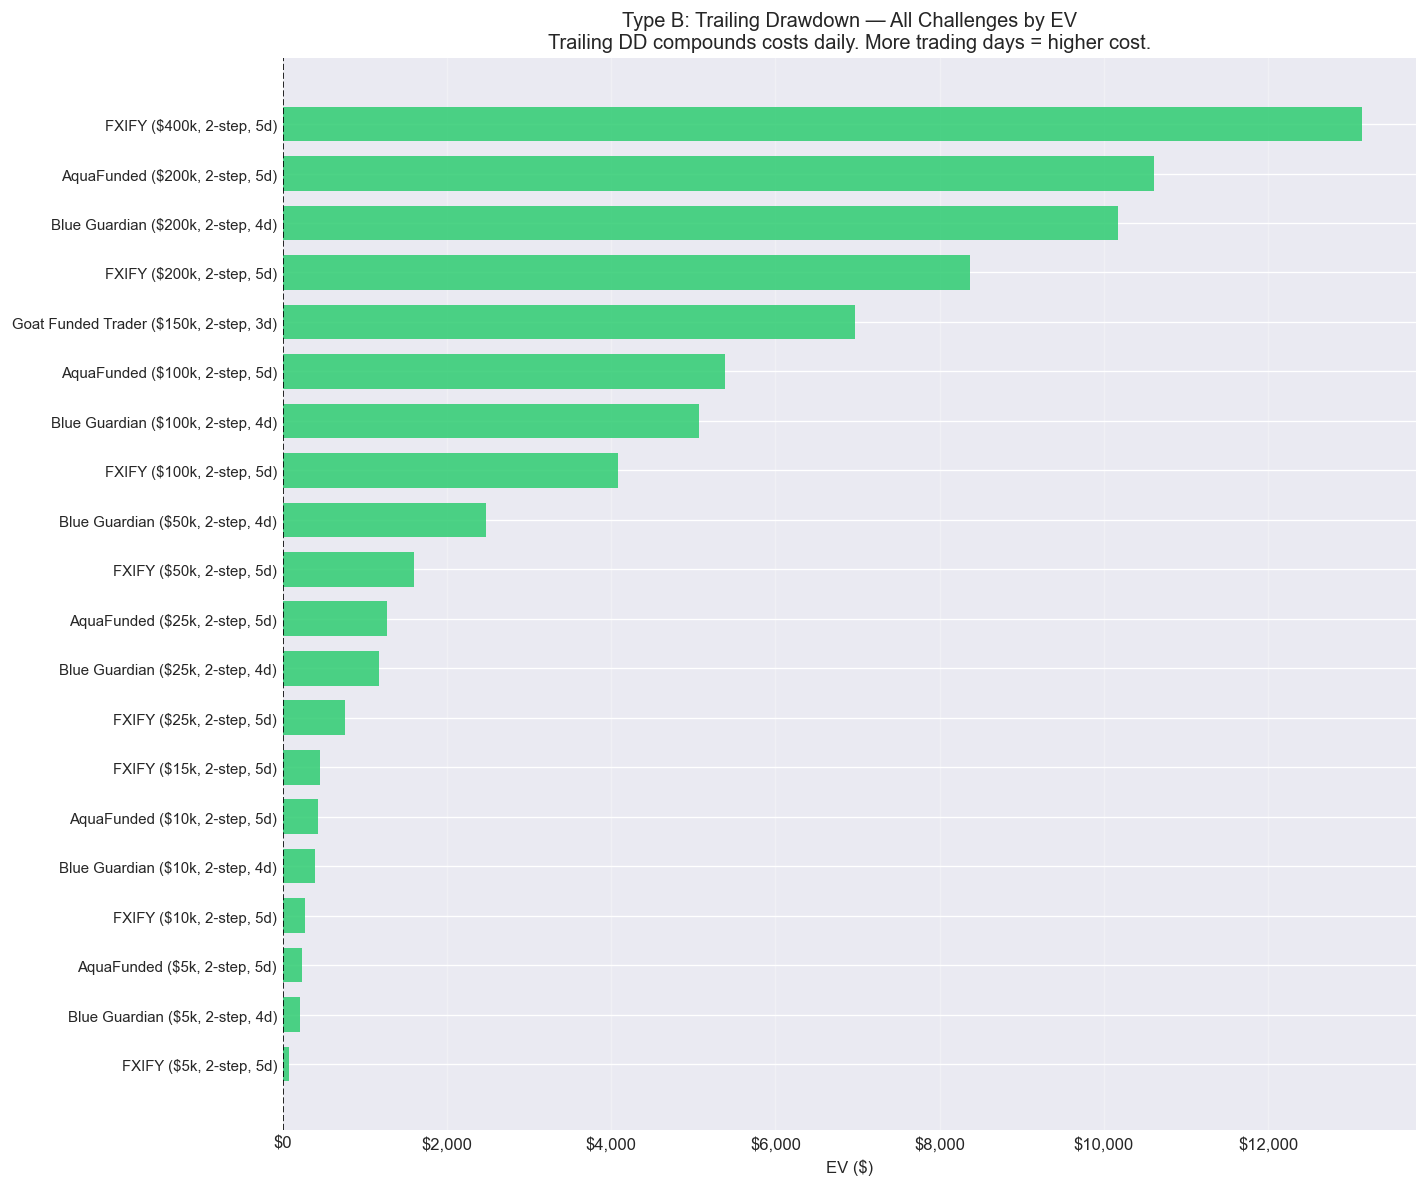

In [5]:
df_show = df.sort_values('EV', ascending=True).copy()
df_show['label'] = df_show.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k, {r['steps']}-step, {r['min_trading_days']}d)", axis=1)

fig, ax = plt.subplots(figsize=(12, max(6, len(df_show) * 0.5)))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_show['EV']]
ax.barh(range(len(df_show)), df_show['EV'], color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(df_show)))
ax.set_yticklabels(df_show['label'], fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('EV ($)')
ax.set_title('Type B: Trailing Drawdown — All Challenges by EV\n'
             'Trailing DD compounds costs daily. More trading days = higher cost.')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Daily Cost Compounding

This chart shows how costs grow **day by day** during each phase. Compare this to Type A where costs grow in big steps per phase — here it's a smooth exponential curve within each phase.

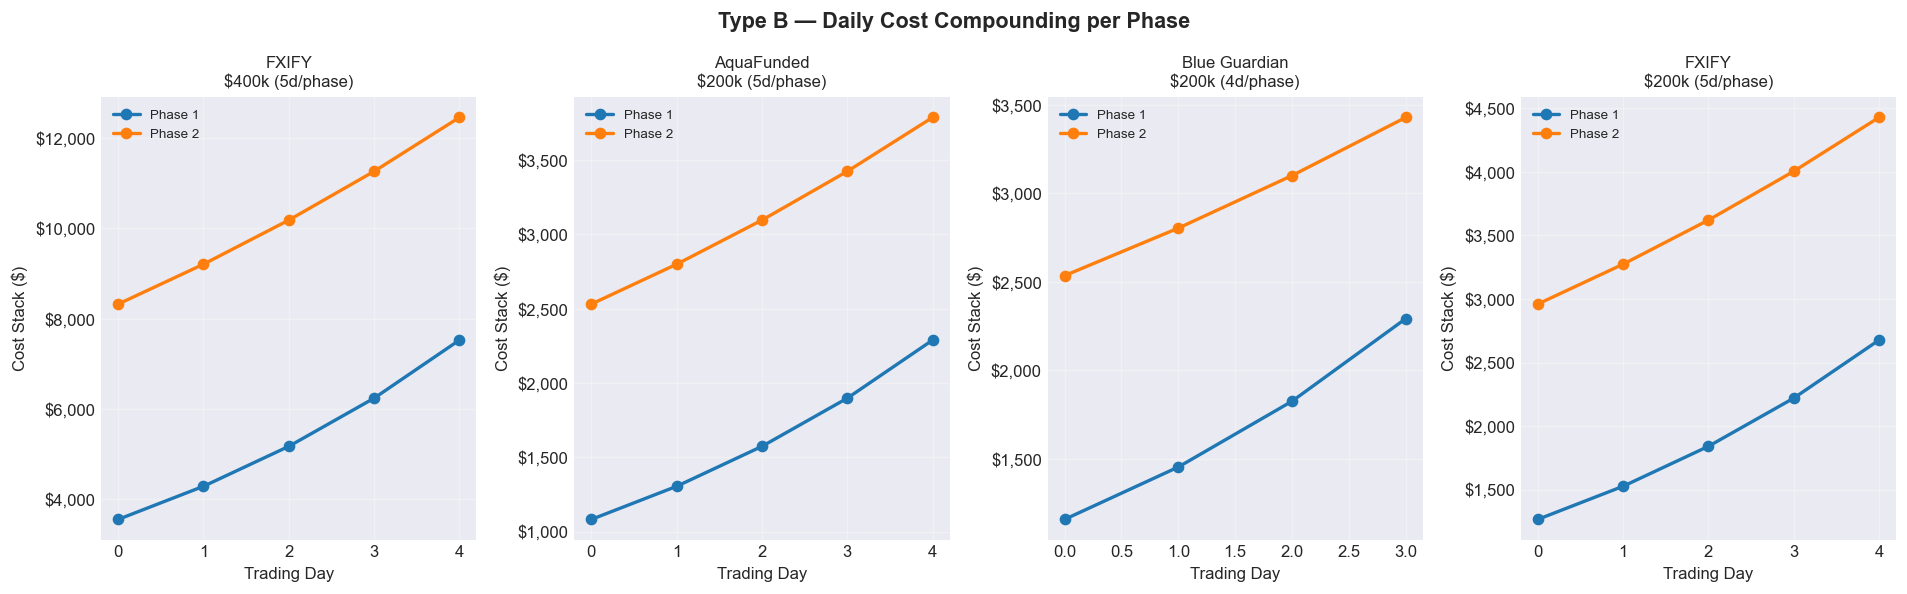

In [6]:
fig, axes = plt.subplots(1, min(len(results), 4), figsize=(16, 5),
                          squeeze=False, sharey=False)
axes = axes.flatten()

for idx, r in enumerate(sorted(results, key=lambda x: x['EV'], reverse=True)[:4]):
    ax = axes[idx]
    dl = pd.DataFrame(r['daily_log'])
    if dl.empty:
        continue

    for phase_num in dl['phase'].unique():
        phase_data = dl[dl['phase'] == phase_num]
        ax.plot(range(len(phase_data)), phase_data['cost_after'],
                marker='o', linewidth=2, label=f'Phase {phase_num}')

    ax.set_title(f"{r['firm']}\n${r['account_size']/1000:.0f}k ({r['min_trading_days']}d/phase)", fontsize=10)
    ax.set_xlabel('Trading Day')
    ax.set_ylabel('Cost Stack ($)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused axes
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Type B — Daily Cost Compounding per Phase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Min Trading Days Impact

How does the number of minimum trading days affect the total cost? More days = more compounding = higher cost. This is the key sensitivity for trailing DD.

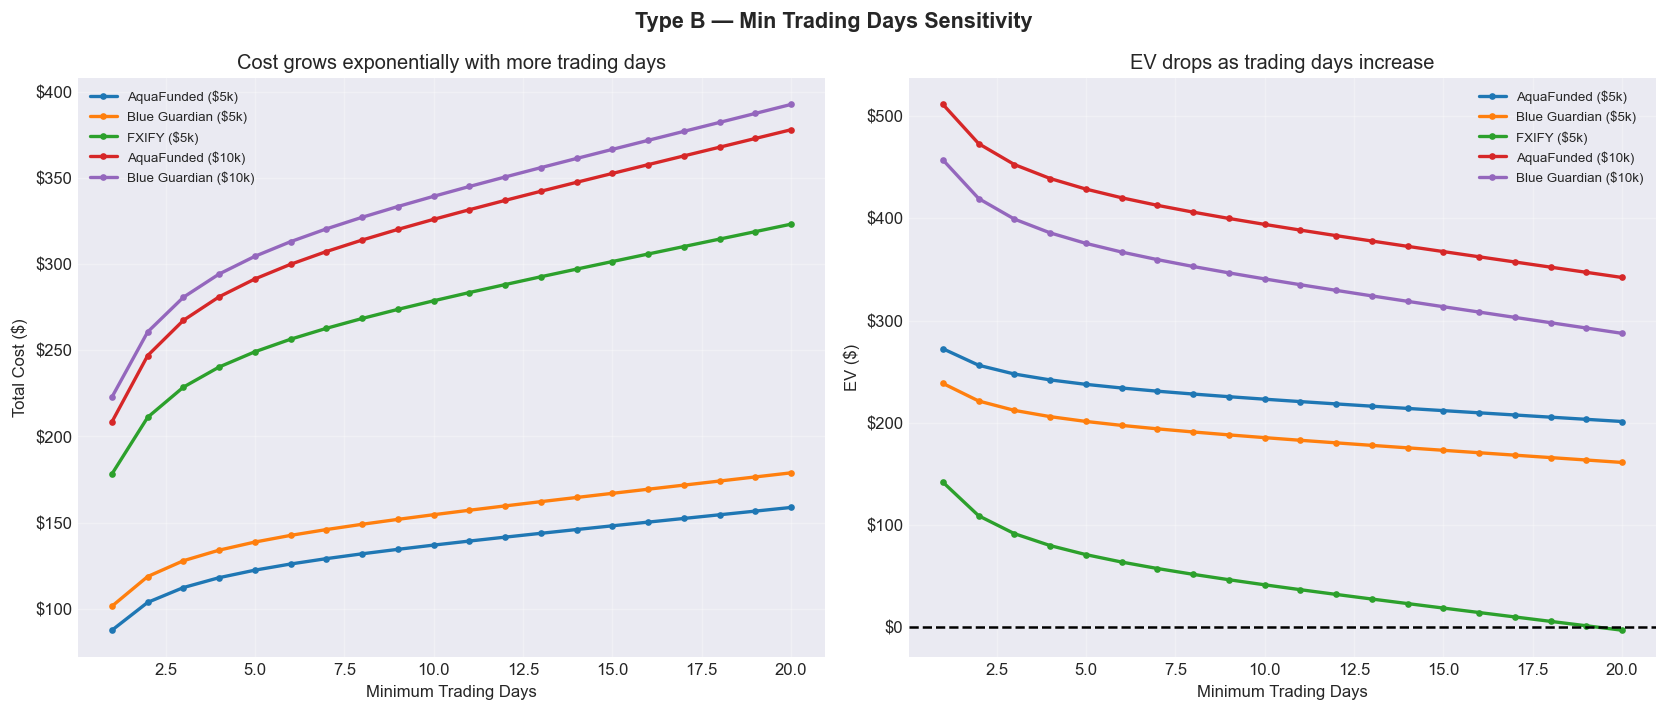

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cm = plt.cm.tab10.colors
days_range = range(1, 21)

for i, ch in enumerate(challenges[:5]):
    costs = []
    evs = []
    for d in days_range:
        ch_mod = dict(ch)
        ch_mod['min_trading_days'] = d
        r = compute_type_b(ch_mod)
        costs.append(r['total_cost'])
        evs.append(r['EV'])
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax1.plot(list(days_range), costs, marker='o', markersize=3, linewidth=2, color=cm[i % 10], label=label)
    ax2.plot(list(days_range), evs, marker='o', markersize=3, linewidth=2, color=cm[i % 10], label=label)

ax1.set_xlabel('Minimum Trading Days')
ax1.set_ylabel('Total Cost ($)')
ax1.set_title('Cost grows exponentially with more trading days')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.set_xlabel('Minimum Trading Days')
ax2.set_ylabel('EV ($)')
ax2.set_title('EV drops as trading days increase')
ax2.axhline(0, color='black', linestyle='--')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Type B — Min Trading Days Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Type A vs Type B Cost Comparison

Side-by-side: what does the same challenge cost under static vs trailing drawdown rules?

$100k account, 10% DD, targets 8%+5%, fee $500

 min_days  Type A Cost  Type A EV  Type B Cost  Type B EV  Extra Cost (B vs A)
        1    $1,359.92  $5,040.08    $1,359.92  $5,040.08                $0.00
        3    $1,379.86  $5,020.14    $1,662.03  $4,737.97              $282.17
        5    $1,399.95  $5,000.05    $1,783.36  $4,616.64              $383.41
       10    $1,450.80  $4,949.20    $1,967.47  $4,432.53              $516.67
       15    $1,502.55  $4,897.45    $2,117.30  $4,282.70              $614.75
       20    $1,555.20  $4,844.80    $2,263.48  $4,136.52              $708.28


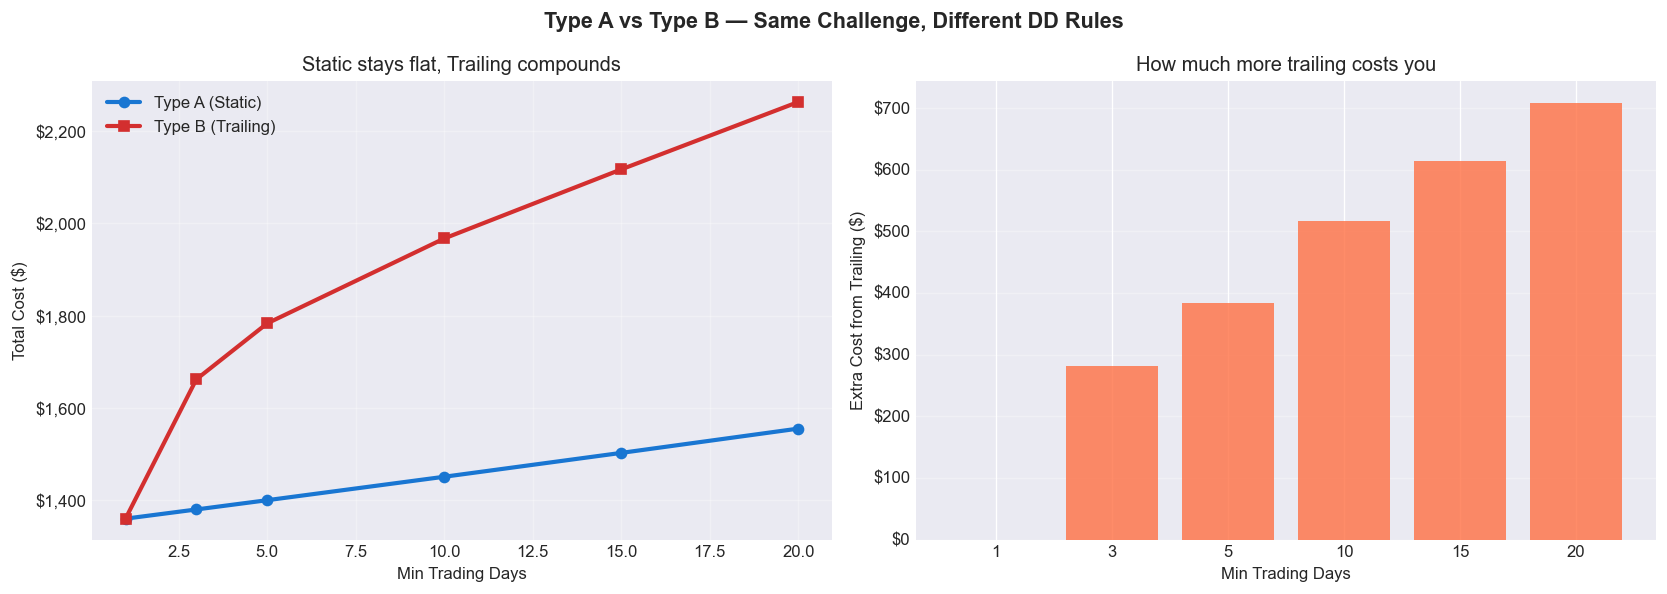

In [8]:
# Simple static-DD compute for comparison (Type A logic)
def _compute_static(challenge, funded_target=FUNDED_TARGET, spread_cost=SPREAD_COST):
    S = challenge['account_size']
    fee = challenge.get('fee_assumed') or challenge.get('fee_discounted') or 0
    activation_fee = challenge.get('activation_fee') or 0
    targets = challenge.get('profit_targets') or []
    steps = challenge.get('steps') or len(targets) or 2
    dd_pct = (challenge.get('max_drawdown_pct') or 10) / 100
    split = (challenge.get('profit_split_pct') or 80) / 100
    min_days = max(int(challenge.get('min_trading_days') or 1), 1)
    if isinstance(targets, str):
        targets = json.loads(targets)
    phase_targets = [t / 100 for t in targets] if targets else [0.08 / steps] * steps
    L = float(fee)
    for i in range(steps):
        target = phase_targets[i] if i < len(phase_targets) else phase_targets[-1]
        hedge_size = L / dd_pct if dd_pct > 0 else 0
        spread_total = hedge_size * spread_cost * 2 * min_days
        L += hedge_size * target + spread_total
    L += float(activation_fee)
    funded_payout = S * funded_target * split
    return {'total_cost': round(L, 2), 'EV': round(funded_payout - L, 2)}

# Compare: $100k, 10% DD, 8%+5% targets, 5 min days
comparison = {
    'firm': 'Example', 'account_size': 100000, 'fee_assumed': 500,
    'max_drawdown_pct': 10, 'profit_split_pct': 80,
    'profit_targets': [8, 5], 'steps': 2, 'activation_fee': 0,
}

day_range = [1, 3, 5, 10, 15, 20]
rows_cmp = []
for d in day_range:
    ch_mod = dict(comparison)
    ch_mod['min_trading_days'] = d
    r_a = _compute_static(ch_mod)
    r_b = compute_type_b(ch_mod)
    rows_cmp.append({
        'min_days': d,
        'Type A Cost': r_a['total_cost'], 'Type A EV': r_a['EV'],
        'Type B Cost': r_b['total_cost'], 'Type B EV': r_b['EV'],
        'Extra Cost (B vs A)': r_b['total_cost'] - r_a['total_cost'],
    })

df_cmp = pd.DataFrame(rows_cmp)
print("$100k account, 10% DD, targets 8%+5%, fee $500\n")
print(df_cmp.to_string(index=False, float_format='${:,.2f}'.format))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(df_cmp['min_days'], df_cmp['Type A Cost'], 'o-', linewidth=2.5, label='Type A (Static)', color='#1976d2')
ax1.plot(df_cmp['min_days'], df_cmp['Type B Cost'], 's-', linewidth=2.5, label='Type B (Trailing)', color='#d32f2f')
ax1.set_xlabel('Min Trading Days')
ax1.set_ylabel('Total Cost ($)')
ax1.set_title('Static stays flat, Trailing compounds')
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

ax2.bar([str(d) for d in df_cmp['min_days']], df_cmp['Extra Cost (B vs A)'], color='#ff7043', alpha=0.8)
ax2.set_xlabel('Min Trading Days')
ax2.set_ylabel('Extra Cost from Trailing ($)')
ax2.set_title('How much more trailing costs you')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Type A vs Type B — Same Challenge, Different DD Rules', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### What Type B means for you
- **Same idea as Type A** — hedge through challenges, get funded — but trailing drawdown makes it more expensive
- The drawdown floor follows your highest balance, so the hedge must grow each day
- **Min trading days directly controls cost:** more days = more compounding = higher cost
- The daily target (phase target ÷ min days) is the key metric — it determines how fast costs compound

### Key takeaway
- A trailing DD challenge with 5 min trading days costs noticeably more than the same challenge with static DD
- The cost difference grows exponentially: 10 days costs much more than 2× what 5 days costs
- When comparing Type B challenges, always check min trading days — a lower fee doesn't help if the compounding eats it

### When to use Type B
- Challenges that specify trailing/EOD drawdown rules
- Firms where the only good offers have trailing DD
- When you want to understand *exactly* how much the trailing penalty costs you

> **Not hedgeable:** Intra-day trailing drawdown (where the floor moves tick-by-tick during the trading day) cannot be hedged safely and is excluded from this model.